# Fixed-truth recovery study

Simulate data from **one** known parameter point, refit the production
K=3 signed MIRT, and ask whether the multimodal "islands" reappear. If they do
under a single-truth generator, the multimodality is intrinsic to
model + observation-pattern + noise (report via stacking / mode-restriction).
If the refit converges, islands need real data features (e.g. the Skilled
Generalist straddler). Truth is a single posterior draw: it is exactly
model-realizable and rotation-orbit-proof (any orbit point gives the same eta).

**Pre-registered verdict thresholds** (calibrated to campaign history: converged
fits had D-spread 0.19-0.47 and logp spread < 10 nats; island fits had
D-spread >= 1.7 and logp spread 26-173 nats; 20 nats is the basin cutoff).

| verdict | criteria |
|---|---|
| CONVERGED | eta & D max identified r-hat <= 1.05 **and** max D-spread < 0.5 **and** logp spread < 10 nats |
| ISLANDS | max D-spread > 1.0 **or** logp spread > 20 nats **or** eta max identified r-hat > 1.1 |
| AMBIGUOUS | anything between |

**Interpretation map.**
- Arm 1 (truth from converged no-SG fit, two seeds): both CONVERGED -> islands
  not intrinsic (data-driven); both ISLANDS -> intrinsic to design+noise; split
  -> near-threshold, ambiguous.
- Arm 2 (truths from two basins of the with-SG fit): each refit closer to its
  own truth's D than the other's -> basins are separable generating stories;
  both landing on the same story -> current coverage can't distinguish them.

In [1]:
import dataclasses
import gc
import json
import sys
from pathlib import Path

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from scipy.cluster.hierarchy import fcluster, linkage
from scipy.spatial.distance import pdist, squareform

ROOT = Path.cwd().parent if Path.cwd().name == "diagnostics" else Path.cwd()
sys.path.insert(0, str(ROOT))

from config import HUMAN_ORDER, SAMPLE_KW
from data import load_eci_data
from lineage import build_lineage_structure
from fit import sample_mirt
from ppc import posterior_predictive_mirt
from analysis import mirt_identified_rhat
from persistence import load_trace, save_trace

OUT = ROOT / "results" / "recovery_study"
OUT.mkdir(parents=True, exist_ok=True)

NOSG_TRACE = (ROOT / "results/mirt_signed_humanprior_lineageprior_noSG"
              / "trace_mirt_k3_signed_humanprior_lineageprior_noSG.nc")

# exact production config, screening scale (only knob changed vs canonical)
REFIT_KW = {**SAMPLE_KW, "draws": 1000, "tune": 1000, "chains": 8, "cores": 8,
            "nuts_sampler": "nutpie"}

# data seeds vary per synthetic dataset; sampler seed stays 42 (in SAMPLE_KW)
SIM_SEEDS = {"arm1_a": 1001, "arm1_b": 1002, "arm2_A": 2001, "arm2_B": 2002}

# a chain within this many nats of the best chain-mean logp is the same basin
BASIN_NATS = 20.0

THRESHOLDS = {
    "island_dspread": 1.0, "island_logp": 20.0, "island_eta_rhat": 1.1,
    "conv_rhat": 1.05, "conv_dspread": 0.5, "conv_logp": 10.0,
}

In [2]:
data = load_eci_data(include_all_benchmarks=True)
assert (data.n_models, data.n_benchmarks) == (751, 85), (data.n_models, data.n_benchmarks)
lineage = build_lineage_structure(data.mlookup)

sg_id0 = int(data.mlookup.loc[data.mlookup["model"] == "Skilled Generalist",
                              "model_idx"].iloc[0]) - 1
n_sg = int((data.model_idx == sg_id0).sum())
n_chains = 0 if lineage is None else lineage.n_chains
print(f"{data.n_obs} obs / {data.n_models} models / {data.n_benchmarks} benchmarks | "
      f"SG cells = {n_sg} | lineage chains = {n_chains}")

4051 obs / 751 models / 85 benchmarks | SG cells = 10 | lineage chains = 36


In [3]:
def d_spread(post):
    cmean = post["D"].mean("draw").values          # (chain, bench)
    return cmean.max(0) - cmean.min(0)             # (bench,)


def ward_basins(post, k=2):
    cmean = post["D"].mean("draw").values
    z = (cmean - cmean.mean(0)) / (cmean.std(0) + 1e-9)
    dist = squareform(pdist(z))
    labels = fcluster(linkage(z, "ward"), t=k, criterion="maxclust")
    return labels, dist


def panel_stats(idata):
    post = idata.posterior
    logp = idata.sample_stats["logp"].mean("draw").values
    labels, dist = ward_basins(post)
    div = (int(idata.sample_stats["diverging"].sum())
           if "diverging" in idata.sample_stats else -1)
    return {"logp": logp, "logp_spread": float(logp.max() - logp.min()),
            "dspread": d_spread(post), "dspread_max": float(d_spread(post).max()),
            "chain_dist": dist, "basins": labels, "divergences": div,
            "benches": list(post["bench"].values)}


def add_rhat(stats, idata, fitdata):
    ident = mirt_identified_rhat(idata, fitdata)
    stats["eta_rhat"] = ident["eta_max_rhat"]
    stats["D_rhat"] = ident.get("D_max_rhat", float("nan"))
    stats["sigma_b_rhat"] = ident.get("sigma_b_max_rhat", float("nan"))
    return stats


def verdict(s):
    t = THRESHOLDS
    if (s["eta_rhat"] <= t["conv_rhat"] and s["D_rhat"] <= t["conv_rhat"]
            and s["dspread_max"] < t["conv_dspread"]
            and s["logp_spread"] < t["conv_logp"]):
        return "CONVERGED"
    if (s["dspread_max"] > t["island_dspread"] or s["logp_spread"] > t["island_logp"]
            or s["eta_rhat"] > t["island_eta_rhat"]):
        return "ISLANDS"
    return "AMBIGUOUS"


def island_panel(s, title):
    fig, ax = plt.subplots(1, 3, figsize=(15, 4))
    below = s["logp"] - s["logp"].max()
    ax[0].bar(range(len(below)), below)
    ax[0].axhline(-BASIN_NATS, ls="--", c="r")
    ax[0].set(title="chain mean logp (nats below best)", xlabel="chain")
    order = np.argsort(s["dspread"])[::-1][:8]
    ax[1].barh([s["benches"][i] for i in order][::-1], s["dspread"][order][::-1])
    ax[1].axvline(THRESHOLDS["island_dspread"], ls="--", c="r")
    ax[1].set(title="top cross-chain D-spread")
    im = ax[2].imshow(s["chain_dist"], cmap="viridis")
    ax[2].set(title="chain distance (z-scored mean D)", xlabel="chain", ylabel="chain")
    fig.colorbar(im, ax=ax[2])
    fig.suptitle(f"{title}  |  logp spread {s['logp_spread']:.0f} nats  "
                 f"D-spread {s['dspread_max']:.2f}  div {s['divergences']}")
    fig.tight_layout()
    plt.show()

In [4]:
def _eta_one(A, th, D, ci, di):
    e = -D[ci, di, data.bench_idx].astype(float)
    for k in range(A.shape[-1]):
        e += A[ci, di, data.bench_idx, k] * th[ci, di, data.model_idx, k]
    return e


def select_truth_draw(post_ds, chains, max_draws=1000):
    # truth = the single (chain, draw) whose full-pattern eta is closest (RMSE)
    # to the basin-mean eta; restricted to `chains` so a stray island is excluded
    sub = post_ds.isel(chain=chains)
    A, th, D = sub["A"].values, sub["theta"].values, sub["D"].values
    flat = [(c, d) for c in range(A.shape[0]) for d in range(A.shape[1])]
    sel = np.linspace(0, len(flat) - 1, min(max_draws, len(flat))).astype(int)
    etas = np.array([_eta_one(A, th, D, *flat[i]) for i in sel])
    mean_eta = etas.mean(0)
    rmse = np.sqrt(((etas - mean_eta) ** 2).mean(1))
    lc, d = flat[sel[int(np.argmin(rmse))]]
    return int(chains[lc]), int(d), float(rmse.min())


def simulate_scores(post_ds, chain, draw, seed):
    one = az.InferenceData(posterior=post_ds.isel(chain=[chain], draw=[draw]))
    return posterior_predictive_mirt(one, data, seed=seed, max_draws=1)[0]


def make_synth(scores):
    return dataclasses.replace(data, scores=scores, zero_score_mask=(scores == 0.0))

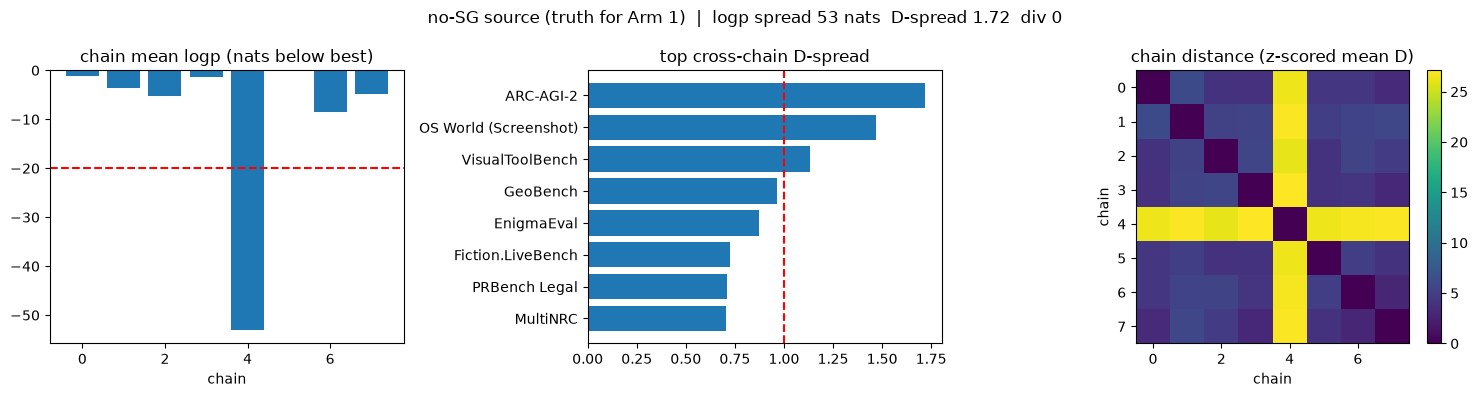

no-SG majority chains (within 20.0 nats) = [0, 1, 2, 3, 5, 6, 7] | eta r-hat 1.284  D r-hat 1.296


In [5]:
# no-SG truth source: shows the chain-4 island -> truth selection is
# basin-restricted to the majority chains
nosg_post = xr.open_dataset(NOSG_TRACE, group="posterior")
nosg_ss = xr.open_dataset(NOSG_TRACE, group="sample_stats")
nosg = add_rhat(panel_stats(az.InferenceData(posterior=nosg_post, sample_stats=nosg_ss)),
                az.InferenceData(posterior=nosg_post), data)
island_panel(nosg, "no-SG source (truth for Arm 1)")

nosg_logp = nosg["logp"]
nosg_majority = [c for c in range(len(nosg_logp))
                 if nosg_logp[c] > nosg_logp.max() - BASIN_NATS]
print(f"no-SG majority chains (within {BASIN_NATS} nats) = {nosg_majority} | "
      f"eta r-hat {nosg['eta_rhat']:.3f}  D r-hat {nosg['D_rhat']:.3f}")


Fitting MIRT  K = 3  (signed loadings, ordered-human prior, lineage prior, sampler=nutpie)  (4051 obs / 751 models / 85 benchmarks)


  starting nutpie sampler at t=0 (no live heartbeat with this backend)


/Users/yassineessifi/Desktop/ECI_Bayesian/multiaxis_eci/models/mirt.py:272: UserWarning: loading_prior='signed' with the ordered human/lineage theta blocks: those blocks are NOT rotation-invariant across axes (their per-axis increments softly prefer certain orientations), so the rotation symmetry is only APPROXIMATE and per-draw alignment is an approximation rather than an exact quotient. Flip side: the structured priors act as a weak, substantive orientation anchor. Interpret aligned axes with that caveat.
  warnings.warn(


Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.04,511
,2000,0,0.03,1023
,2000,0,0.04,511
,2000,0,0.03,511
,2000,641,0.04,7
,2000,0,0.04,255
,2000,3,0.04,127
,2000,0,0.04,511


  sampling done in 438.8s, computing log-likelihood...


Output()

  K=3: raw max r̂=2.449 (label-switching, ignore for K>1)  divergences=644 / 8000


        identified: eta r̂ max=1.184 mean=1.012 (frac>1.01=0.30)  D r̂=1.184  sigma_b r̂=1.194


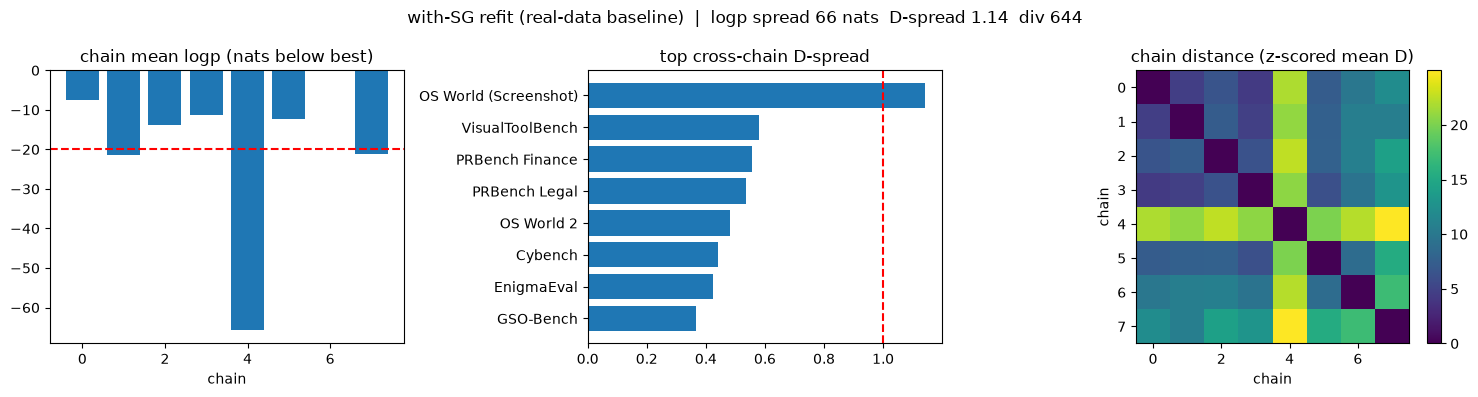

withSG_refit -> ISLANDS  (eta r-hat 1.184)


In [6]:
RESULTS = {}


def run_and_read(name, fitdata, title):
    path = OUT / f"trace_{name}.nc"
    if path.exists():
        idata = load_trace(path)
    else:
        idata, _ = sample_mirt(fitdata, 3, REFIT_KW, human_order=HUMAN_ORDER,
                               lineage=lineage, loading_prior="signed")
        save_trace(idata, path)
    s = add_rhat(panel_stats(idata), idata, fitdata)
    s["verdict"] = verdict(s)
    island_panel(s, title)
    print(f"{name} -> {s['verdict']}  (eta r-hat {s['eta_rhat']:.3f})")
    RESULTS[name] = s
    del idata
    gc.collect()


run_and_read("withSG_refit", data, "with-SG refit (real-data baseline)")

In [7]:
withsg_post = xr.open_dataset(OUT / "trace_withSG_refit.nc", group="posterior")
withsg_ss = xr.open_dataset(OUT / "trace_withSG_refit.nc", group="sample_stats")
wlogp = withsg_ss["logp"].mean("draw").values
wlabels, _ = ward_basins(withsg_post)

best = int(np.argmax(wlogp))
basinA = [c for c in range(len(wlabels)) if wlabels[c] == wlabels[best]]
basinB = [c for c in range(len(wlabels)) if wlabels[c] != wlabels[best]]
arm2_ok = len(basinB) > 0
print(f"basin A (high logp) = {basinA} | basin B = {basinB} | Arm 2 runnable: {arm2_ok}")
if not arm2_ok:
    print("with-SG refit landed single-basin -> Arm 2 not runnable today (recorded).")

basin A (high logp) = [0, 1, 2, 3, 5, 6, 7] | basin B = [4] | Arm 2 runnable: True


Arm-1 truth = chain 3 draw 1110 (eta-RMSE to basin mean 0.171)


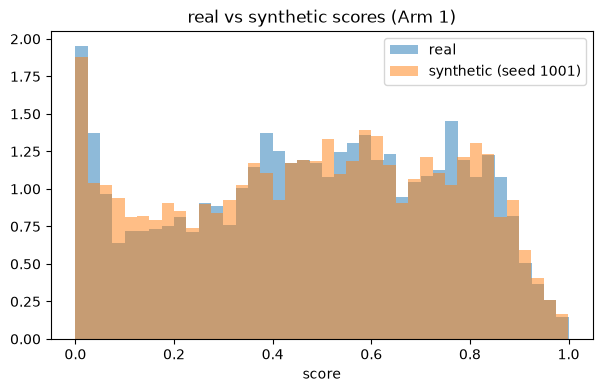

In [8]:
SYNTH = {}
TRUTH = {}

t_chain, t_draw, t_rmse = select_truth_draw(nosg_post, nosg_majority)
TRUTH["arm1"] = {"source": "noSG", "chain": t_chain, "draw": t_draw, "eta_rmse": t_rmse}
print(f"Arm-1 truth = chain {t_chain} draw {t_draw} (eta-RMSE to basin mean {t_rmse:.3f})")

SYNTH["arm1_seed1001"] = simulate_scores(nosg_post, t_chain, t_draw, SIM_SEEDS["arm1_a"])
SYNTH["arm1_seed1002"] = simulate_scores(nosg_post, t_chain, t_draw, SIM_SEEDS["arm1_b"])

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(data.scores, bins=40, alpha=0.5, density=True, label="real")
ax.hist(SYNTH["arm1_seed1001"], bins=40, alpha=0.5, density=True, label="synthetic (seed 1001)")
ax.legend()
ax.set(title="real vs synthetic scores (Arm 1)", xlabel="score")
plt.show()


Fitting MIRT  K = 3  (signed loadings, ordered-human prior, lineage prior, sampler=nutpie)  (4051 obs / 751 models / 85 benchmarks)


  starting nutpie sampler at t=0 (no live heartbeat with this backend)


/Users/yassineessifi/Desktop/ECI_Bayesian/multiaxis_eci/models/mirt.py:272: UserWarning: loading_prior='signed' with the ordered human/lineage theta blocks: those blocks are NOT rotation-invariant across axes (their per-axis increments softly prefer certain orientations), so the rotation symmetry is only APPROXIMATE and per-draw alignment is an approximation rather than an exact quotient. Flip side: the structured priors act as a weak, substantive orientation anchor. Interpret aligned axes with that caveat.
  warnings.warn(


Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.04,511
,2000,0,0.04,255
,2000,0,0.04,1023
,2000,0,0.04,1023
,2000,0,0.04,511
,2000,0,0.04,127
,2000,0,0.04,255
,2000,0,0.04,511


  sampling done in 506.9s, computing log-likelihood...


Output()

  K=3: raw max r̂=1.767 (label-switching, ignore for K>1)  divergences=0 / 8000


        identified: eta r̂ max=1.003 mean=1.000 (frac>1.01=0.00)  D r̂=1.007  sigma_b r̂=1.008


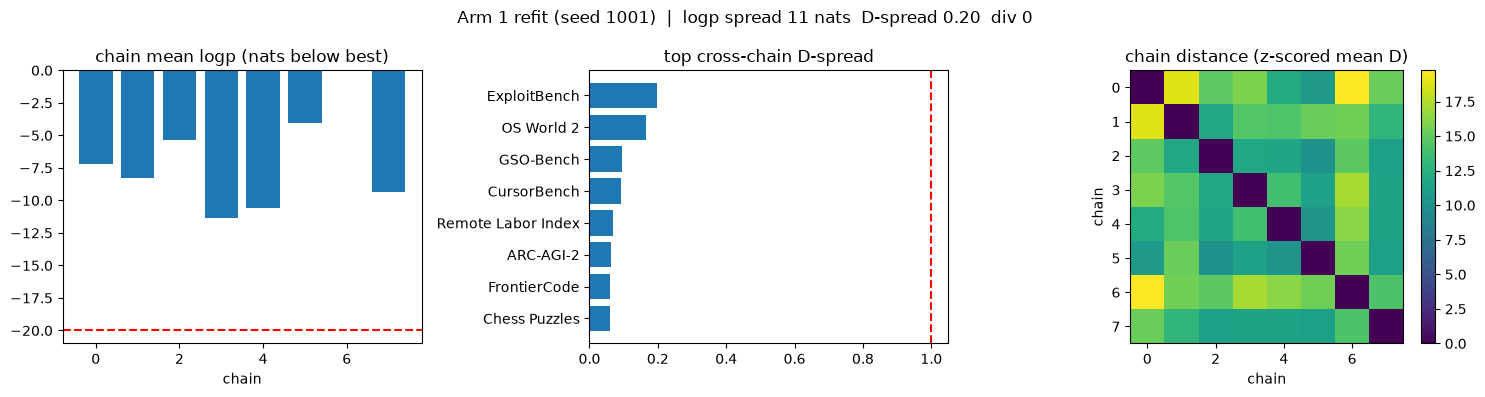

arm1_seed1001 -> AMBIGUOUS  (eta r-hat 1.003)


In [9]:
run_and_read("arm1_seed1001", make_synth(SYNTH["arm1_seed1001"]), "Arm 1 refit (seed 1001)")


Fitting MIRT  K = 3  (signed loadings, ordered-human prior, lineage prior, sampler=nutpie)  (4051 obs / 751 models / 85 benchmarks)


  starting nutpie sampler at t=0 (no live heartbeat with this backend)


/Users/yassineessifi/Desktop/ECI_Bayesian/multiaxis_eci/models/mirt.py:272: UserWarning: loading_prior='signed' with the ordered human/lineage theta blocks: those blocks are NOT rotation-invariant across axes (their per-axis increments softly prefer certain orientations), so the rotation symmetry is only APPROXIMATE and per-draw alignment is an approximation rather than an exact quotient. Flip side: the structured priors act as a weak, substantive orientation anchor. Interpret aligned axes with that caveat.
  warnings.warn(


Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,9,0.04,511
,2000,1,0.04,127
,2000,0,0.04,255
,2000,1,0.04,127
,2000,18,0.03,1023
,2000,0,0.04,255
,2000,0,0.04,127
,2000,561,0.04,5


  sampling done in 505.4s, computing log-likelihood...


Output()

  K=3: raw max r̂=2.793 (label-switching, ignore for K>1)  divergences=590 / 8000


        identified: eta r̂ max=1.161 mean=1.005 (frac>1.01=0.09)  D r̂=1.505  sigma_b r̂=1.277


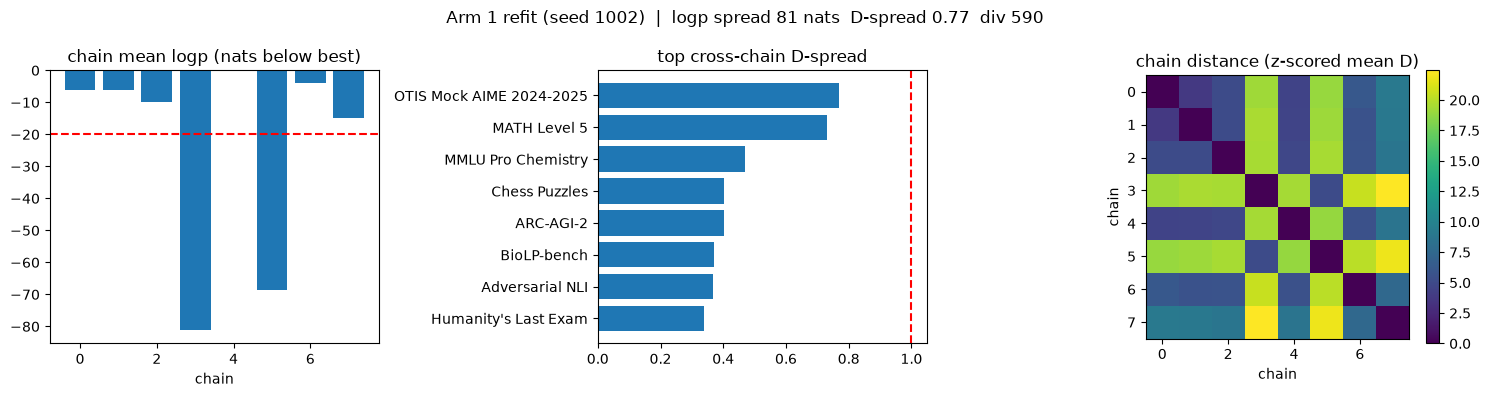

arm1_seed1002 -> ISLANDS  (eta r-hat 1.161)


In [10]:
run_and_read("arm1_seed1002", make_synth(SYNTH["arm1_seed1002"]), "Arm 1 refit (seed 1002)")

Arm-2 truth A = chain 1 draw 695 | truth B = chain 4 draw 770

Fitting MIRT  K = 3  (signed loadings, ordered-human prior, lineage prior, sampler=nutpie)  (4051 obs / 751 models / 85 benchmarks)


  starting nutpie sampler at t=0 (no live heartbeat with this backend)


/Users/yassineessifi/Desktop/ECI_Bayesian/multiaxis_eci/models/mirt.py:272: UserWarning: loading_prior='signed' with the ordered human/lineage theta blocks: those blocks are NOT rotation-invariant across axes (their per-axis increments softly prefer certain orientations), so the rotation symmetry is only APPROXIMATE and per-draw alignment is an approximation rather than an exact quotient. Flip side: the structured priors act as a weak, substantive orientation anchor. Interpret aligned axes with that caveat.
  warnings.warn(


Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,74,0.03,255
,2000,10,0.03,511
,2000,16,0.04,255
,2000,50,0.03,511
,2000,0,0.03,255
,2000,24,0.03,511
,2000,0,0.03,255
,2000,24,0.03,255


  sampling done in 527.3s, computing log-likelihood...


Output()

  K=3: raw max r̂=2.525 (label-switching, ignore for K>1)  divergences=198 / 8000


        identified: eta r̂ max=1.278 mean=1.013 (frac>1.01=0.20)  D r̂=1.309  sigma_b r̂=1.205


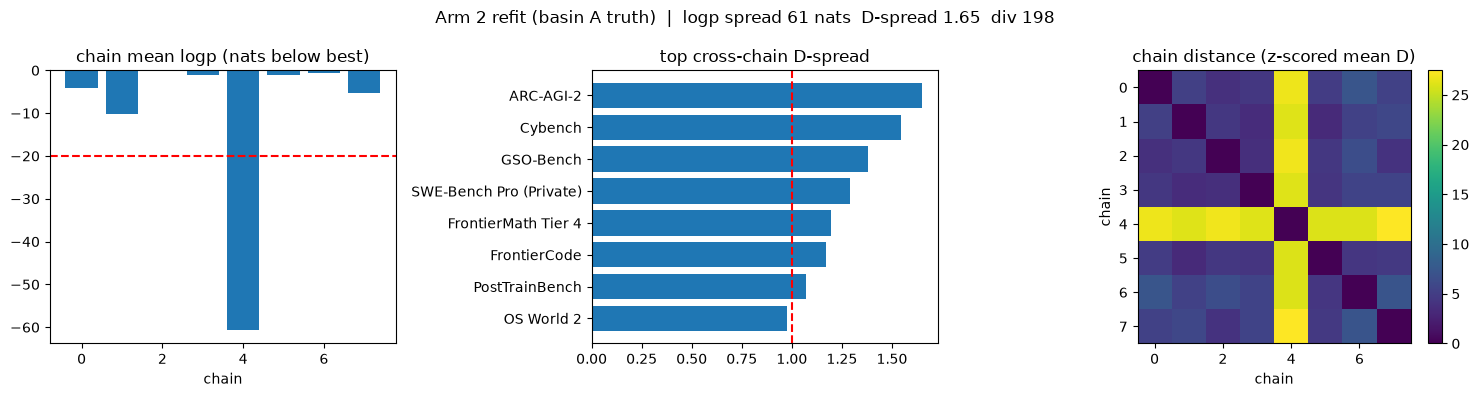

arm2_basinA -> ISLANDS  (eta r-hat 1.278)

Fitting MIRT  K = 3  (signed loadings, ordered-human prior, lineage prior, sampler=nutpie)  (4051 obs / 751 models / 85 benchmarks)


  starting nutpie sampler at t=0 (no live heartbeat with this backend)


/Users/yassineessifi/Desktop/ECI_Bayesian/multiaxis_eci/models/mirt.py:272: UserWarning: loading_prior='signed' with the ordered human/lineage theta blocks: those blocks are NOT rotation-invariant across axes (their per-axis increments softly prefer certain orientations), so the rotation symmetry is only APPROXIMATE and per-draw alignment is an approximation rather than an exact quotient. Flip side: the structured priors act as a weak, substantive orientation anchor. Interpret aligned axes with that caveat.
  warnings.warn(


Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.04,255
,2000,0,0.04,255
,2000,0,0.03,255
,2000,0,0.03,255
,2000,0,0.04,511
,2000,0,0.03,511
,2000,0,0.03,255
,2000,0,0.03,511


  sampling done in 487.8s, computing log-likelihood...


Output()

  K=3: raw max r̂=2.326 (label-switching, ignore for K>1)  divergences=0 / 8000


        identified: eta r̂ max=1.005 mean=1.000 (frac>1.01=0.00)  D r̂=1.003  sigma_b r̂=1.021


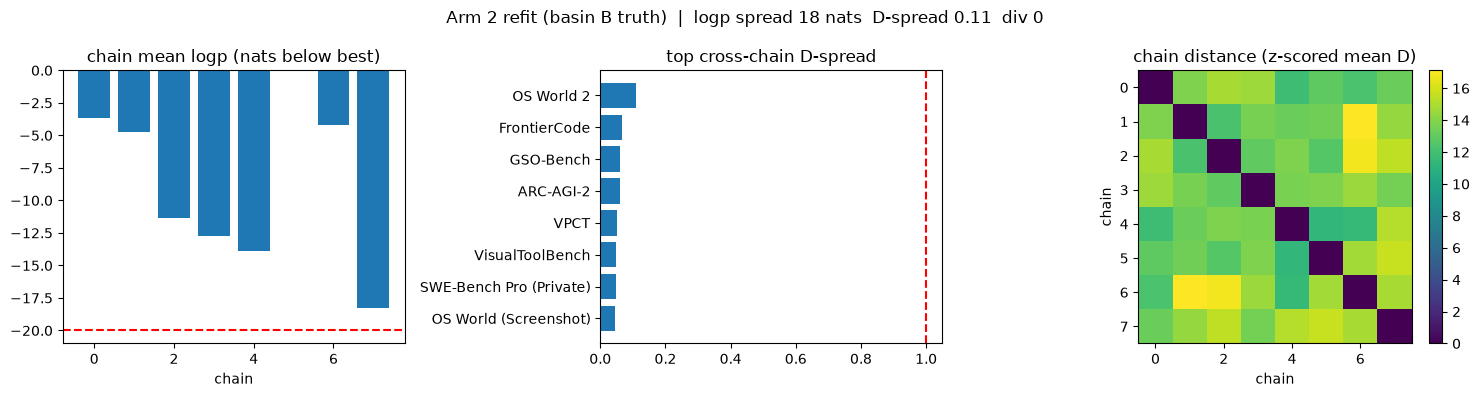

arm2_basinB -> AMBIGUOUS  (eta r-hat 1.005)


In [11]:
if arm2_ok:
    ca, da, ra = select_truth_draw(withsg_post, basinA)
    cb, db, rb = select_truth_draw(withsg_post, basinB)
    TRUTH["arm2_basinA"] = {"source": "withSG", "chain": ca, "draw": da, "eta_rmse": ra}
    TRUTH["arm2_basinB"] = {"source": "withSG", "chain": cb, "draw": db, "eta_rmse": rb}
    SYNTH["arm2_basinA"] = simulate_scores(withsg_post, ca, da, SIM_SEEDS["arm2_A"])
    SYNTH["arm2_basinB"] = simulate_scores(withsg_post, cb, db, SIM_SEEDS["arm2_B"])
    print(f"Arm-2 truth A = chain {ca} draw {da} | truth B = chain {cb} draw {db}")
    run_and_read("arm2_basinA", make_synth(SYNTH["arm2_basinA"]), "Arm 2 refit (basin A truth)")
    run_and_read("arm2_basinB", make_synth(SYNTH["arm2_basinB"]), "Arm 2 refit (basin B truth)")
else:
    print("Arm 2 skipped (single-basin with-SG refit).")

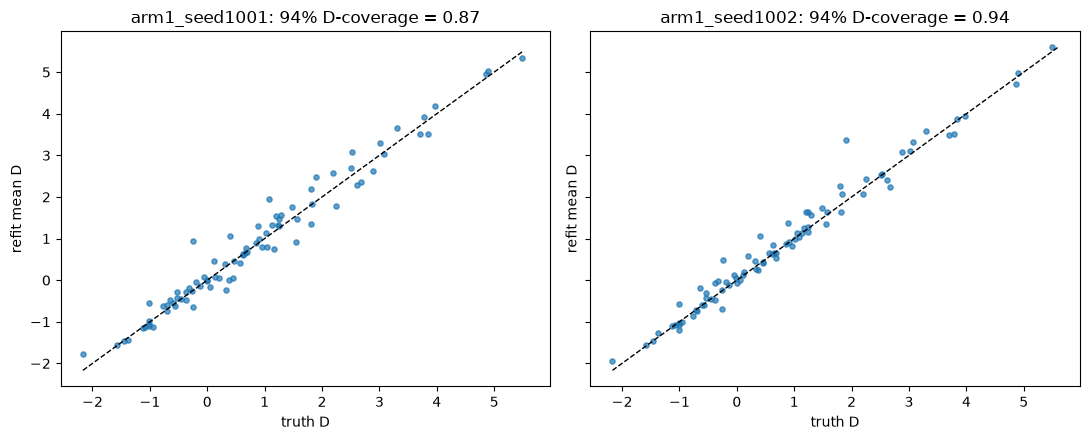

      refit own_truth  RMSE_vs_A  RMSE_vs_B  recovers_own
arm2_basinA         A   0.259597   0.321352          True
arm2_basinB         B   0.378563   0.263293          True


In [12]:
def truth_D(source_post, chain, draw):
    return source_post["D"].isel(chain=chain, draw=draw).values   # (bench,)


def d_coverage(name, source_post, chain, draw):
    idata = load_trace(OUT / f"trace_{name}.nc")
    hdi = az.hdi(idata, var_names=["D"], hdi_prob=0.94)["D"].values  # (bench, 2)
    D_ref = idata.posterior["D"].mean(("chain", "draw")).values
    del idata
    gc.collect()
    Dt = truth_D(source_post, chain, draw)
    cover = float(((Dt >= hdi[:, 0]) & (Dt <= hdi[:, 1])).mean())
    return D_ref, Dt, cover


# Arm 1: truth-D 94% HDI coverage is the study's internal self-test
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5), sharex=True, sharey=True)
for a, name in zip(ax, ["arm1_seed1001", "arm1_seed1002"]):
    D_ref, Dt, cover = d_coverage(name, nosg_post, TRUTH["arm1"]["chain"], TRUTH["arm1"]["draw"])
    RESULTS[name]["D_coverage"] = cover
    lim = [min(Dt.min(), D_ref.min()), max(Dt.max(), D_ref.max())]
    a.plot(lim, lim, "k--", lw=1)
    a.scatter(Dt, D_ref, s=14, alpha=0.7)
    a.set(title=f"{name}: 94% D-coverage = {cover:.2f}", xlabel="truth D", ylabel="refit mean D")
plt.tight_layout()
plt.show()

# Arm 2: separability -- each refit should sit closer to its OWN truth's D
if arm2_ok:
    DA = truth_D(withsg_post, TRUTH["arm2_basinA"]["chain"], TRUTH["arm2_basinA"]["draw"])
    DB = truth_D(withsg_post, TRUTH["arm2_basinB"]["chain"], TRUTH["arm2_basinB"]["draw"])
    rows = []
    for name, own in [("arm2_basinA", "A"), ("arm2_basinB", "B")]:
        idata = load_trace(OUT / f"trace_{name}.nc")
        D_ref = idata.posterior["D"].mean(("chain", "draw")).values
        del idata
        gc.collect()
        rmse_A = float(np.sqrt(((D_ref - DA) ** 2).mean()))
        rmse_B = float(np.sqrt(((D_ref - DB) ** 2).mean()))
        rows.append({"refit": name, "own_truth": own,
                     "RMSE_vs_A": rmse_A, "RMSE_vs_B": rmse_B,
                     "recovers_own": (rmse_A < rmse_B) == (own == "A")})
    sep = pd.DataFrame(rows)
    print(sep.to_string(index=False))

In [13]:
cols = ["verdict", "dspread_max", "logp_spread", "eta_rhat", "D_rhat",
        "divergences", "D_coverage"]
table = pd.DataFrame(
    [{"fit": k, **{c: RESULTS[k].get(c, float("nan")) for c in cols}}
     for k in RESULTS]
).set_index("fit")
print(table.to_string(float_format=lambda x: f"{x:.3f}"))
table.to_csv(OUT / "recovery_verdicts.csv")

pd.DataFrame(SYNTH).to_csv(OUT / "synth_scores.csv", index=False)
with open(OUT / "truth_draws.json", "w") as f:
    json.dump({"truth": TRUTH, "sim_seeds": SIM_SEEDS}, f, indent=2)
print("wrote", OUT / "recovery_verdicts.csv")

                 verdict  dspread_max  logp_spread  eta_rhat  D_rhat  divergences  D_coverage
fit                                                                                          
withSG_refit     ISLANDS        1.142       65.797     1.184   1.184          644         NaN
arm1_seed1001  AMBIGUOUS        0.198       11.348     1.003   1.007            0       0.871
arm1_seed1002    ISLANDS        0.768       81.271     1.161   1.505          590       0.941
arm2_basinA      ISLANDS        1.648       60.763     1.278   1.309          198         NaN
arm2_basinB    AMBIGUOUS        0.110       18.264     1.005   1.003            0         NaN
wrote /Users/yassineessifi/Desktop/ECI_Bayesian/results/recovery_study/recovery_verdicts.csv
